In [ ]:
%pip install datasets

In [7]:
from datasets import load_dataset, Dataset, Image as Img
import glob
import os
import cv2
from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import io
from model import PointLiteNet
from torch.utils.data import DataLoader
from IPython.display import clear_output
import random
import torchvision


device = "cuda" if torch.cuda.is_available() else "cpu"


NUM_POINTS = 500

/home/lanv/Faks/mag/venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x) * 200 - 100
    amount = amount.view(-1, 1, 1)  # sort shape so broadcasting works
    return x * (1 - amount) + noise * amount

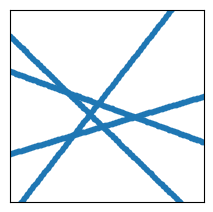

In [13]:


def plot_data(data):
    my_dpi = 100
    fig, ax = plt.subplots(frameon=False, figsize=(250/my_dpi, 250/my_dpi), dpi=my_dpi)
    ax.scatter(data[0], data[1], s=10)
    ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False) 
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.autoscale(tight=True)
    ax.set_ylim(-100, 100)
    return fig


def generate_data(num_points, lines_count):
    out = None
    for i in range(lines_count):
        x = torch.linspace(-100, 100, num_points//lines_count)
        k = random.random()*4 - 2
        n = random.randint(-50, 50)
        y = k * x + n
        # noise = torch.rand_like(y)
        # y = y * (1 - amount) + noise * amount
        if(out == None):
            out = torch.vstack((x,y))
        else:
            out = torch.hstack((out,torch.vstack((x,y))))
    return out

data = generate_data(NUM_POINTS, 4)
fig = plot_data(data)
fig.show()


torch.Size([2, 500]) <class 'torch.Tensor'>


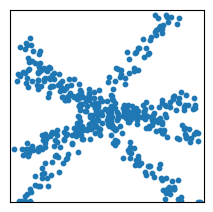

In [15]:
print(data.shape, type(data))

plot_data(corrupt(data.unsqueeze(0), torch.ones(data.shape).unsqueeze(0)*0.1)[0]).show()

In [16]:
from typing import List


class PointsDataset(Dataset):
    def __init__(self, num_points:int, num_lines:int):
        self.num_points = num_points
        self.num_lines = num_lines
        
    def __len__(self):
        return 5000

    def __getitem__(self, idx):
        item = torch.vstack([generate_data(num_points=self.num_points, lines_count=self.num_lines) for i in idx])
        return item
    
    def __getitems__(self, keys: List) -> List:
        return [generate_data(num_points=self.num_points, lines_count=self.num_lines) for i in keys]

train_dataset = PointsDataset(NUM_POINTS, 4)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=64)

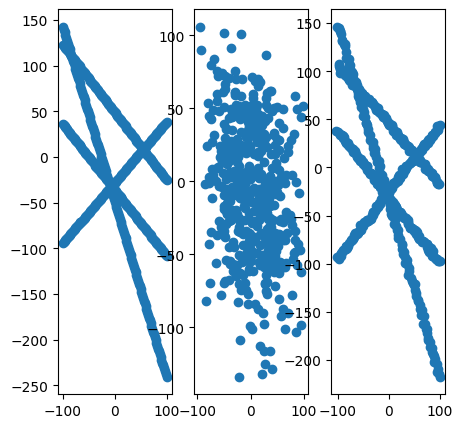

Finished epoch 49. Average loss for this epoch: 100.557058


(0.0, 0.1)

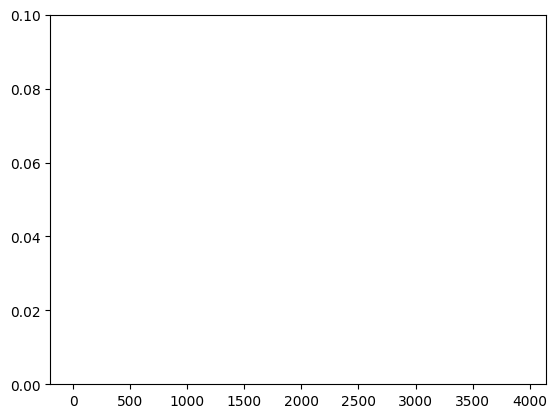

In [17]:
# How many runs through the data should we do?
n_epochs = 50

# Create the netork
net = PointLiteNet(NUM_POINTS, 2)
net.to(device)

# Our loss function
loss_fn = torch.nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for i, x in enumerate(train_dataloader):

        # Get some data and prepare the corrupted version
        x = x.to(device)  # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) * 0.8  # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount)  # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x)

        # print(x.shape, noisy_x.shape, pred.shape)


        # print(pred.shape, x.shape, noisy_x.shape)
        # Calculate the loss
        loss = loss_fn(pred, x)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())
        
        if(i%1000 == 0):
            fig, axs = plt.subplots(1,3, figsize=(5,5))

            clear_output()
            xc = x.detach().cpu().numpy()
            nxc = noisy_x.detach().cpu().numpy()
            pc = pred.detach().cpu().numpy()

            axs[0].scatter(xc[0][0], xc[0][1])
            axs[1].scatter(nxc[0][0], nxc[0][1])
            axs[2].scatter(pc[0][0], pc[0][1])

            fig.show()
            plt.show()


    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
    print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}")

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1)

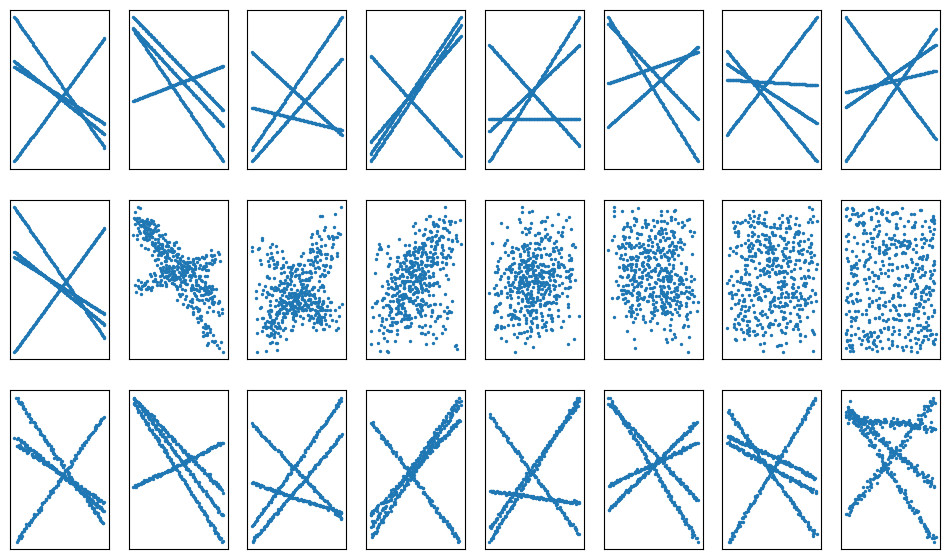

In [18]:
# @markdown Visualizing model predictions on noisy inputs:

# Fetch some data
x = next(iter(train_dataloader))
x = x[:8]  # Only using the first 8 for easy plotting

# Corrupt with a range of amounts
amount = torch.linspace(0, 1, x.shape[0])  # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Get the model predictions
with torch.no_grad():
    preds = net(noised_x.to(device)).detach().cpu()

# Plot
fig, axs = plt.subplots(3, x.shape[0], figsize=(12, 7))
for i, data in enumerate(x):
    axs[0][i].scatter(data[0], data[1], s=2)
    axs[0][i].get_xaxis().set_visible(False)
    axs[0][i].get_yaxis().set_visible(False)

for i, data in enumerate(noised_x):
    axs[1][i].scatter(data[0], data[1], s=2)
    axs[1][i].get_xaxis().set_visible(False)
    axs[1][i].get_yaxis().set_visible(False)

for i, data in enumerate(preds):
    axs[2][i].scatter(data[0], data[1], s=2)
    axs[2][i].get_xaxis().set_visible(False)
    axs[2][i].get_yaxis().set_visible(False)
# axs[1].set_title("Corrupted 

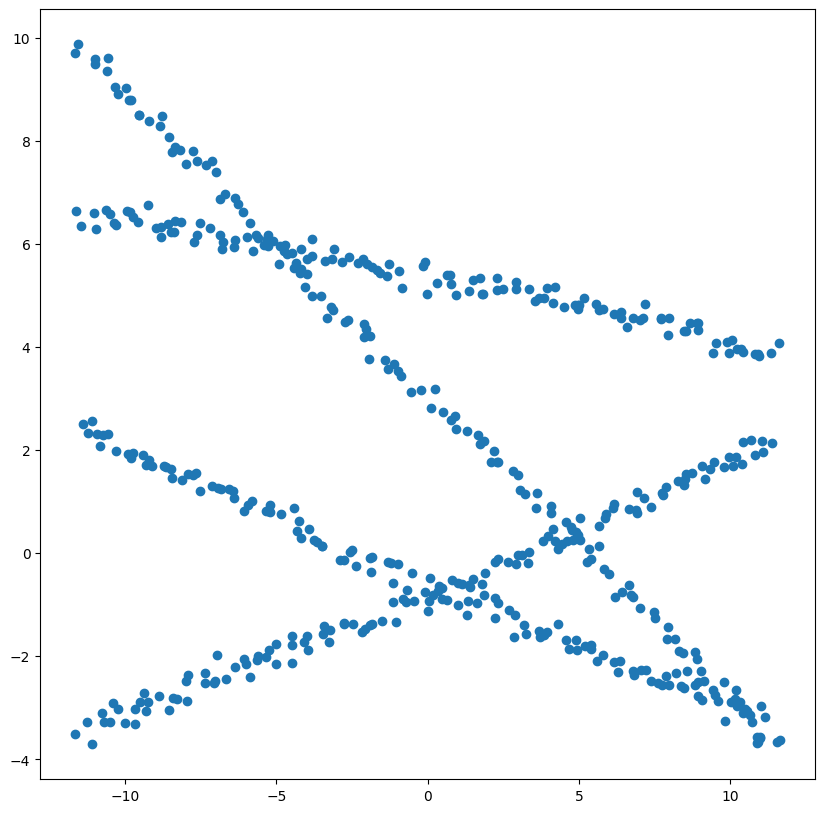

In [23]:
n_steps = 50
x = torch.rand(1, 2, NUM_POINTS).to(device)

for i in range(n_steps):
    noise_amount = torch.ones((x.shape[0],)).to(device) * (1 - (i / n_steps))  # Starting high going low
    with torch.no_grad():
        pred = net(x)
    mix_factor = 1 / (n_steps - i)
    x = x * (1 - mix_factor) + pred * mix_factor

x = x.squeeze(0).detach().cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(x[0], x[1])